# Capítulo 15: Aplicaciones: filtrado y compresión

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfbonder/imc/blob/main/notebooks/08-aplicaciones.ipynb)

Notebook que acompaña al Capítulo 15 (Aplicaciones del análisis de Fourier) de *Introducción al Modelado Continuo*. Reproduce las dos aplicaciones del texto: el **filtrado de ruido** de una señal unidimensional (una suma de tres cosenos con ruido blanco, su espectro, el filtro por umbral y la señal filtrada) y la **compresión de una imagen** por truncamiento espectral (conservar el 3 %, 1 %, 0.1 % y 0.01 % de los coeficientes de la FFT bidimensional de mayor módulo). En el medio volvemos al problema conductor, la **temperatura horaria**, y respondemos con estas herramientas las preguntas 1, 2 y 4 de la Sección "Problema conductor": cuánta energía tienen los ciclos, qué queda al quitarlos y con cuántos coeficientes se reconstruye la serie con un error dado.

**Convención.** La misma del texto y del notebook anterior: $\hat u[k] = \sum_{j=0}^{N-1} u[j]\,e^{-2\pi i jk/N}$ es `np.fft.fft`, y $|\hat u[k]|/N$ es la amplitud (mitad de la amplitud $A_k$ del coseno correspondiente) que graficamos en los espectros. La identidad de Plancherel discreta, $\sum_j|u[j]|^2 = \frac1N\sum_k|\hat u[k]|^2$, es la que permite hablar de la "energía" que la señal tiene en cada frecuencia, y en dos dimensiones (`np.fft.fft2`) vale igual con $N^2$ en lugar de $N$.

In [1]:
# Configuración (funciona en Colab y en una copia local del repositorio)
try:
    import imc
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/jfbonder/imc.git"], check=True)
    import imc

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from skimage import data as skdata, color as skcolor, io as skio
from imc import estilo, espectro, datos
from imc.estilo import COLORES, CICLO

estilo.activar(fuente=14)   # las figuras van a 0.6-0.7\textwidth (~9-11 cm): fuente grande para que se lean impresas
GUARDAR = False   # True para regenerar las figuras de las notas en figuras/


def fuente(F):
    '''Contexto con fuente F en ejes y ticks (leyenda F-2) para las figuras de varios paneles (van a 0.8-0.95\textwidth).'''
    return plt.rc_context({"font.size": F, "axes.labelsize": F, "axes.titlesize": F, "xtick.labelsize": F - 1,
                           "ytick.labelsize": F - 1, "legend.fontsize": F - 2, "lines.linewidth": 2.0})


def error_relativo(u, v):
    '''||u - v||_2 / ||u||_2.'''
    return np.linalg.norm(u - v) / np.linalg.norm(u)


def truncar(F, fraccion):
    '''Anula todos los coeficientes de F salvo la fracción `fraccion` de mayor módulo. Devuelve (F truncada, cantidad conservada).'''
    M = max(1, int(round(fraccion * F.size)))
    umbral = np.sort(np.abs(F).ravel())[-M]                 # el M-ésimo módulo más grande
    conservar = np.abs(F) >= umbral
    ejes = tuple(range(F.ndim))
    conservar |= np.flip(np.roll(conservar, -1, axis=ejes), axis=ejes)   # si entra (k, m) entra (-k, -m): la reconstrucción queda real
    return np.where(conservar, F, 0), int(conservar.sum())

## 15.1 Filtrado de ruido en señales unidimensionales

La señal del texto: $s(t) = \sum_{j=1}^3 a_j\cos(2\pi f_j t + \varphi_j)$ con frecuencias $f_j = 5, 12, 20$ Hz y amplitudes $a_j = 1, 0.6, 0.4$, muestreada durante $T = 1$ s a $f_s = 1000$ Hz ($N = 1000$), y la señal observada $u = s + \eta$ con $\eta$ ruido blanco gaussiano de desvío $\sigma = 0.8$ (más grande que la amplitud de dos de los tres cosenos). **Figura `señal1`**: arriba $s$, abajo $u$.

N = 1000 muestras, f_s = 1000 Hz, resolución en frecuencia 1/T = 1 Hz, Nyquist 500 Hz
energía media de s: 0.760 (= sum a_j^2/2 = 0.760);  del ruido: 0.612 (sigma^2 = 0.64);  error relativo de u respecto de s: 0.897


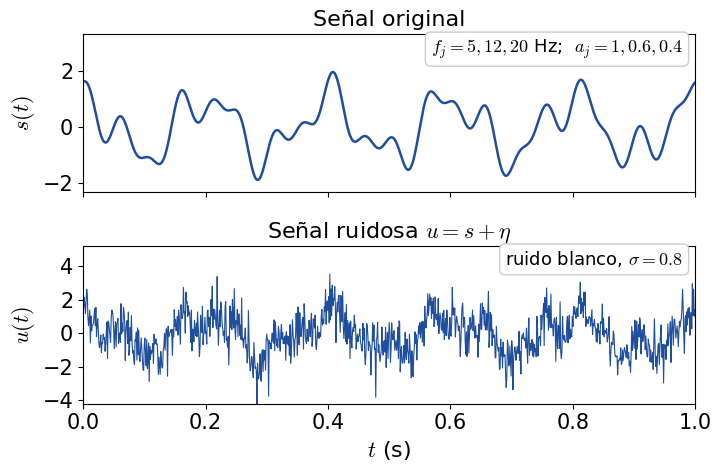

In [2]:
fs, T_s = 1000, 1.0
N = int(fs * T_s); t = np.arange(N) / fs
frec, amp, fase = [5, 12, 20], [1.0, 0.6, 0.4], [0.0, 0.7, -1.2]
s = sum(a * np.cos(2 * np.pi * f * t + p) for f, a, p in zip(frec, amp, fase))
rng = np.random.default_rng(0)
sigma = 0.8
u = s + sigma * rng.normal(size=N)
print(f"N = {N} muestras, f_s = {fs} Hz, resolución en frecuencia 1/T = {1 / T_s:g} Hz, Nyquist {fs / 2:g} Hz")
print(f"energía media de s: {np.mean(s**2):.3f} (= sum a_j^2/2 = {sum(a**2 / 2 for a in amp):.3f});  del ruido: {np.mean((u - s)**2):.3f} (sigma^2 = {sigma**2:.2f});  error relativo de u respecto de s: {error_relativo(s, u):.3f}")

with fuente(16):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.5, 5), sharex=True)
    ax1.plot(t, s, color=COLORES["dato"], lw=1.8); ax1.set_ylabel("$s(t)$"); ax1.set_title("Señal original")
    ax2.plot(t, u, color=COLORES["dato"], lw=0.8); ax2.set_ylabel("$u(t)$"); ax2.set_title(r"Señal ruidosa $u = s + \eta$"); ax2.set_xlabel("$t$ (s)")
    ax1.set_xlim(0, 1); ax1.set_ylim(-2.3, 3.3); ax2.set_ylim(-4.2, 5.2); ax1.set_yticks([-2, 0, 2]); ax2.set_yticks([-4, -2, 0, 2, 4])
    estilo.parametros(ax1, r"$f_j = 5, 12, 20$ Hz;  $a_j = 1, 0.6, 0.4$", loc="upper right", fontsize=13)
    estilo.parametros(ax2, rf"ruido blanco, $\sigma = {sigma}$", loc="upper right", fontsize=13)
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "señal1")

**Figura `espectro-señal`**: el espectro de amplitudes $|\hat u[k]|/N$ de la señal ruidosa hasta $40$ Hz. Los tres cosenos aparecen como picos en $5, 12, 20$ Hz de altura $a_j/2$ (exactamente, porque $f_j T$ es entero: no hay fuga espectral), mientras que el ruido blanco se reparte de manera aproximadamente uniforme en todas las frecuencias: cada $|\hat\eta[k]|/N$ es del orden de $\sigma/\sqrt N \approx 0.025$, cuarenta veces menor que el pico más alto aunque $\sigma$ sea comparable a las amplitudes. Esa es la clave del filtrado: en el tiempo señal y ruido se confunden, en frecuencia no.

In [3]:
U = np.fft.fft(u); S = np.fft.fft(s)
xi = np.arange(N) / T_s                                   # xi_k = k/T en Hz
A_u = np.abs(U) / N
m = xi <= 40
print("|hat u[k]|/N en los picos:", {f: f"{A_u[int(f * T_s)]:.3f} (a_j/2 = {a / 2})" for f, a in zip(frec, amp)})
ruido = np.delete(A_u[1:N // 2], [f - 1 for f in frec])
print(f"|hat eta[k]|/N fuera de los picos: media {ruido.mean():.4f}, máximo {ruido.max():.4f}  (sigma/sqrt(N) = {sigma / np.sqrt(N):.4f})")

with fuente(15):
    fig, ax = plt.subplots(figsize=(7, 3.4))
    ax.stem(xi[m], A_u[m], linefmt=COLORES["dato"], markerfmt="o", basefmt="k-")
    ax.set_xlabel(r"$\xi$ (Hz)"); ax.set_ylabel(r"$|\hat u[k]|/N$"); ax.set_xlim(-0.5, 40.5); ax.set_ylim(0, 0.56)
    ax.set_title("Espectro de la señal ruidosa")
    if GUARDAR: estilo.guardar(fig, "espectro-señal")

|hat u[k]|/N en los picos: {5: '0.496 (a_j/2 = 0.5)', 12: '0.291 (a_j/2 = 0.3)', 20: '0.221 (a_j/2 = 0.2)'}
|hat eta[k]|/N fuera de los picos: media 0.0218, máximo 0.0683  (sigma/sqrt(N) = 0.0253)


### Filtrado en el dominio de Fourier

El filtro más simple: $H(k) = 1$ si $|\hat u[k]|/N$ supera un umbral y $0$ si no; acá el umbral es el $20\%$ del pico más alto. Como $u$ es real, $|\hat u[-k]| = |\hat u[k]|$ y el filtro conserva automáticamente los pares $\pm k$, así que la antitransformada $u_{\rm filtrada} = \mathcal F^{-1}(H\hat u)$ es real. **Figura `espectro-filtrado`**: el espectro original, el umbral y el espectro filtrado (correcciones respecto de la figura original: la leyenda dice "umbral" y no "Threshold", y las etiquetas "Original"/"Filtrado" están en el orden correcto). **Figura `señal-filtrada`**: $u$ y $u_{\rm filtrada}$. El filtro conserva $6$ de los $1000$ coeficientes y recupera $s$ con un error relativo de unos pocos por ciento: lo único que queda es el ruido que cae en esos seis coeficientes. Como $\mathbb E|\hat\eta[k]|^2 = N\sigma^2$, por Plancherel la energía media de ese resto es $6\sigma^2/N$ y el error relativo esperado es $\sqrt{6\sigma^2/N}\,/\sqrt{\overline{s^2}} \approx 0.07$, contra $\sigma/\sqrt{\overline{s^2}} \approx 0.92$ antes de filtrar.

In [4]:
umbral = 0.2 * A_u.max()
H = (A_u > umbral).astype(float)                          # función de transferencia H(k) in {0, 1}
u_f = np.fft.ifft(H * U).real
print(f"umbral = 0.2 max |hat u|/N = {umbral:.4f}; H(k) = 1 en {int(H.sum())} de {N} coeficientes: k = {np.flatnonzero(H)} (frecuencias {xi[H > 0][:3]} Hz y sus negativas)")
print(f"max |Im F^-1(H hat u)| = {np.abs(np.fft.ifft(H * U).imag).max():.1e} (la señal filtrada es real)")
print(f"error relativo respecto de s:  antes de filtrar {error_relativo(s, u):.3f};  después {error_relativo(s, u_f):.3f}  (esperado ~ sqrt(6 sigma^2 / N) / sqrt(mean s^2) = {np.sqrt(6 * sigma**2 / N / np.mean(s**2)):.3f})")
u_f2 = espectro.filtrar(u, 1 / fs, lambda f: np.isin(np.round(f), frec).astype(float))   # lo mismo con imc.espectro.filtrar (máscara sobre las frecuencias no negativas)
print(f"coincide con espectro.filtrar: {np.allclose(u_f, u_f2)}")

umbral = 0.2 max |hat u|/N = 0.0991; H(k) = 1 en 6 de 1000 coeficientes: k = [  5  12  20 980 988 995] (frecuencias [ 5. 12. 20.] Hz y sus negativas)
max |Im F^-1(H hat u)| = 3.1e-16 (la señal filtrada es real)
error relativo respecto de s:  antes de filtrar 0.897;  después 0.065  (esperado ~ sqrt(6 sigma^2 / N) / sqrt(mean s^2) = 0.071)
coincide con espectro.filtrar: True


In [5]:
with fuente(15):
    fig, ax = plt.subplots(figsize=(7, 3.6))
    ax.axhline(umbral, color="black", ls="--", lw=1.4, label=f"umbral ({umbral:.2f})")
    ax.stem(xi[m], A_u[m], linefmt=COLORES["dato"], markerfmt="o", basefmt="k-", label="original")
    ax.stem(xi[m], (H * A_u)[m], linefmt=COLORES["modelo"], markerfmt="o", basefmt="k-", label="filtrado")
    ax.set_xlabel(r"$\xi$ (Hz)"); ax.set_ylabel(r"$|\hat u[k]|/N$"); ax.set_xlim(-0.5, 40.5); ax.set_ylim(0, 0.56)
    ax.legend(loc="upper right", fontsize=13); ax.set_title("Filtro por umbral: $H(k) = 1$ sobre la línea de trazos")
    if GUARDAR: estilo.guardar(fig, "espectro-filtrado")

    fig, ax = plt.subplots(figsize=(7, 3.6))
    ax.plot(t, u, color=COLORES["traj2"], lw=0.8, label="señal ruidosa $u$")
    ax.plot(t, u_f, color=COLORES["modelo"], lw=2.2, label=r"filtrada $\mathcal{F}^{-1}(H\hat u)$")
    ax.plot(t, s, color="black", lw=1.0, ls="--", label="original $s$")
    ax.set_xlabel("$t$ (s)"); ax.set_ylabel("amplitud"); ax.set_xlim(0, 1); ax.set_ylim(-4, 4.6)
    ax.legend(loc="upper right", ncol=3, fontsize=12, columnspacing=1.0, handlelength=1.6)
    if GUARDAR: estilo.guardar(fig, "señal-filtrada")

## Volvemos al problema: la señal de temperatura

Un año (2023) de temperatura horaria en Aeroparque: $N = 8760$, $T = 1$ año, de modo que $k$ son ciclos por año ($k = 1$ anual, $k = 365$ diario, $k = 730, 1095$ sus armónicos de 12 y 8 horas). **Pregunta 1**: el espectro de potencia $|\hat T[k]|^2/N$ tiene picos en esas frecuencias, y por Plancherel la fracción de la energía total *fuera de la media* que contienen es $\sum_{k\in\text{picos}}|\hat T[k]|^2 / \sum_{k\ne0}|\hat T[k]|^2$ (contando $\pm k$). **Pregunta 2**: el filtro $H(k) = 1$ en $\{0, \pm1, \pm2, \pm365, \pm730, \pm1095\}$ da la "temperatura regular" $T_{\rm reg}$, y el residuo $T - T_{\rm reg}$ es la parte irregular, cuyo espectro miramos en escala log-log en ciclos por día. *Figura nueva `temperatura-filtrado`*: (a) espectro de potencia con los picos marcados; (b) un mes de la señal con $T_{\rm reg}$ superpuesta y el residuo debajo; (c) el periodograma del residuo (fino) y su versión promediada por tramos (método de Welch, tramos de 45 días) en ciclos por día.

In [6]:
ruta = datos.obtener("temperatura_horaria.csv")
df = pd.read_csv(ruta, parse_dates=["fecha_hora"])
d23 = df[df.fecha_hora.dt.year == 2023].reset_index(drop=True)
T = d23.temp.values; N_T = len(T)                          # N = 8760, k en ciclos por año
X = np.fft.fft(T); P = np.abs(X) ** 2 / N_T                  # espectro de potencia; sum_k P[k] = sum_j T[j]^2 (Plancherel)
k = np.arange(N_T)
picos = [1, 2, 365, 730, 1095]
E_total = P[1:].sum()                                      # energía fuera de la media = N var(T)
E_picos = {kk: 2 * P[kk] for kk in picos}                  # +k y -k
print(f"Plancherel: sum_j T[j]^2 = {np.sum(T**2):.1f}, (1/N) sum_k |hat T[k]|^2 = {P.sum():.1f};  N var(T) = {N_T * T.var():.1f} = sum_(k != 0) P[k] = {E_total:.1f}")
print("fracción de la energía (fuera de la media) en cada pico:")
for kk in picos:
    print(f"   k = {kk:4d} ({'anual' if kk == 1 else 'semestral' if kk == 2 else f'{24 // (kk // 365)} h':>9s}): amplitud A_k = {2 * np.abs(X[kk]) / N_T:5.2f} °C, {100 * E_picos[kk] / E_total:5.1f} %")
frac_picos = sum(E_picos.values()) / E_total
print(f"   total en los {len(picos)} picos (10 coeficientes complejos de {N_T}): {100 * frac_picos:.1f} % de la energía;  parte irregular: {100 * (1 - frac_picos):.1f} %")

H_T = np.isin(k, picos) | np.isin(N_T - k, picos) | (k == 0)
T_reg = np.fft.ifft(H_T * X).real                          # temperatura "regular": media + ciclos
resid = T - T_reg
print(f"\nT_reg usa {int(H_T.sum())} coeficientes; desvío de T {T.std():.2f} °C, de T_reg {T_reg.std():.2f} °C, del residuo {resid.std():.2f} °C  (fracción de energía del residuo: {np.mean(resid**2) / T.var():.3f} = 1 - {frac_picos:.3f})")
print(f"residuo: media {resid.mean():.1e} °C, máximo |residuo| = {np.abs(resid).max():.1f} °C, autocorrelación a 1 h {np.corrcoef(resid[:-1], resid[1:])[0, 1]:.3f}, a 24 h {np.corrcoef(resid[:-24], resid[24:])[0, 1]:.3f}, a 7 días {np.corrcoef(resid[:-168], resid[168:])[0, 1]:.3f}")



Plancherel: sum_j T[j]^2 = 3265017.0, (1/N) sum_k |hat T[k]|^2 = 3265017.0;  N var(T) = 349929.3 = sum_(k != 0) P[k] = 349929.3
fracción de la energía (fuera de la media) en cada pico:
   k =    1 (    anual): amplitud A_k =  6.92 °C,  59.9 %
   k =    2 (semestral): amplitud A_k =  0.80 °C,   0.8 %
   k =  365 (     24 h): amplitud A_k =  2.76 °C,   9.5 %
   k =  730 (     12 h): amplitud A_k =  0.83 °C,   0.9 %
   k = 1095 (      8 h): amplitud A_k =  0.07 °C,   0.0 %
   total en los 5 picos (10 coeficientes complejos de 8760): 71.0 % de la energía;  parte irregular: 29.0 %

T_reg usa 11 coeficientes; desvío de T 6.32 °C, de T_reg 5.33 °C, del residuo 3.40 °C  (fracción de energía del residuo: 0.290 = 1 - 0.710)
residuo: media -1.9e-15 °C, máximo |residuo| = 13.5 °C, autocorrelación a 1 h 0.982, a 24 h 0.577, a 7 días 0.013


In [7]:
# espectro del residuo en ciclos por día (dt = 1/24 día): periodograma crudo y promediado por tramos (Welch)
xi_r, P_r = espectro.periodograma(resid, dt=1 / 24)
xi_w, P_w = espectro.welch(resid, dt=1 / 24, tramo=24 * 45)
for lim, txt in [(1 / 30, "más de un mes"), (1 / 7, "más de una semana"), (0.5, "más de 2 días"), (2, "más de 12 h")]:
    print(f"energía del residuo en períodos de {txt:18s} (xi < {lim:.3f} c/día): {100 * P_r[(xi_r > 0) & (xi_r < lim)].sum() / P_r[xi_r > 0].sum():5.1f} %")
sel = (xi_w > 0.03) & (xi_w < 0.5)
pend = np.polyfit(np.log10(xi_w[sel]), np.log10(P_w[sel]), 1)[0]
print(f"pendiente del espectro de Welch en log-log entre 1/30 y 1/2 ciclos por día: {pend:.2f}  (ruido blanco: 0)")

energía del residuo en períodos de más de un mes      (xi < 0.033 c/día):  15.9 %
energía del residuo en períodos de más de una semana  (xi < 0.143 c/día):  58.7 %
energía del residuo en períodos de más de 2 días      (xi < 0.500 c/día):  85.4 %
energía del residuo en períodos de más de 12 h        (xi < 2.000 c/día):  97.6 %
pendiente del espectro de Welch en log-log entre 1/30 y 1/2 ciclos por día: -1.65  (ruido blanco: 0)


In [8]:
mes = (d23.fecha_hora >= "2023-05-01") & (d23.fecha_hora < "2023-06-01")
with fuente(18):
    fig = plt.figure(figsize=(11, 10))
    gs = fig.add_gridspec(2, 1, height_ratios=[1.15, 1.7], hspace=0.4)
    gs_arriba = gs[0].subgridspec(1, 2, wspace=0.3); gs_abajo = gs[1].subgridspec(2, 1, height_ratios=[1, 0.65], hspace=0.12)
    ax_a = fig.add_subplot(gs_arriba[0]); ax_c = fig.add_subplot(gs_arriba[1]); ax_b = fig.add_subplot(gs_abajo[0]); ax_r = fig.add_subplot(gs_abajo[1], sharex=ax_b)
    # (a) espectro de potencia
    ax_a.semilogy(k[1:N_T // 2], P[1:N_T // 2], color=COLORES["dato"], lw=0.5)
    ax_a.plot(picos, [P[kk] for kk in picos], "o", color=COLORES["modelo"], ms=8, zorder=5)
    for kk, txt, dx, dy in [(1, "1: anual", 12, 2), (2, "2", 12, -14), (365, "365: diario", 8, 4), (730, "730: 12 h", 8, 4), (1095, "1095: 8 h", -105, 8)]:
        ax_a.annotate(txt, (kk, P[kk]), (dx, dy), textcoords="offset points", fontsize=14, color=COLORES["modelo"])
    ax_a.set_xlabel("$k$ (ciclos por año)"); ax_a.set_ylabel(r"$|\hat T[k]|^2/N$"); ax_a.set_xlim(-40, 1400); ax_a.set_ylim(1e-1, 1e6); ax_a.set_xticks([0, 365, 730, 1095])
    ax_a.set_title(f"(a) potencia: {100 * frac_picos:.0f} % en los picos")
    # (c) espectro del residuo, log-log en ciclos por día
    ax_c.loglog(xi_r[1:], P_r[1:], color=COLORES["traj2"], lw=0.5, label="periodograma")
    ax_c.loglog(xi_w[1:], P_w[1:], color=COLORES["modelo"], lw=2.2, label="Welch (45 días)")
    for p_dias, txt in [(1, "1 día"), (7, "1 sem."), (30, "1 mes")]:
        ax_c.axvline(1 / p_dias, color="0.5", ls=":", lw=1.2); ax_c.text(1 / p_dias * 1.12, 1.5e-3, txt, fontsize=13, color="0.3", rotation=90, va="bottom")
    ax_c.set_xlabel(r"$\xi$ (ciclos por día)"); ax_c.set_ylabel("potencia"); ax_c.set_xlim(1e-2, 12); ax_c.set_ylim(1e-3, 3e3)
    ax_c.legend(loc="upper right", fontsize=13); ax_c.set_title("(c) espectro del residuo")
    # (b) un mes: señal, regular y residuo
    ax_b.plot(d23.fecha_hora[mes], T[mes], color=COLORES["dato"], lw=1.2, label="temperatura $T$")
    ax_b.plot(d23.fecha_hora[mes], T_reg[mes], color=COLORES["modelo"], lw=2.2, label=r"regular: media $+\ k = 1, 2, 365, 730, 1095$")
    ax_b.set_ylabel("°C"); ax_b.legend(loc="upper center", ncol=2, fontsize=14); ax_b.set_title("(b) mayo de 2023: la temperatura y su parte regular"); ax_b.set_ylim(2, 34); ax_b.set_yticks([5, 15, 25])
    ax_r.plot(d23.fecha_hora[mes], resid[mes], color=COLORES["nul_p"], lw=1.2); ax_r.axhline(0, color="0.5", lw=0.8)
    ax_r.set_ylabel("°C"); ax_r.set_xlabel("fecha (2023)"); ax_r.set_ylim(-9, 11)
    ax_r.text(0.01, 0.95, f"residuo $T - T_{{\\rm reg}}$: desvío {resid.std():.1f} °C, {100 * (1 - frac_picos):.0f} % de la energía", transform=ax_r.transAxes, ha="left", va="top", fontsize=15)
    ax_r.xaxis.set_major_locator(mdates.DayLocator(interval=5)); ax_r.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
    ax_r.set_xlim(pd.Timestamp("2023-05-01"), pd.Timestamp("2023-06-01")); plt.setp(ax_b.get_xticklabels(), visible=False)
    if GUARDAR: estilo.guardar(fig, "temperatura-filtrado")

**Pregunta 4: ¿cuántos números hacen falta?** Es la compresión de la sección siguiente aplicada a la serie: conservar los $M$ coeficientes $\hat T[k]$ de mayor módulo (siempre de a pares $\pm k$, más la media) y antitransformar. Por Plancherel no hace falta reconstruir para conocer el error: $\|T - T_M\|_2^2 = \frac1N\sum_{k\notin\text{conservados}}|\hat T[k]|^2$. *Figura nueva `temperatura-compresion`*: error relativo $\|T - T_M\|/\|T\|$ en función de $M$ (log-log), con los $M$ necesarios para un $10$, $5$ y $1\%$. Como la media ($18$ °C) es el coeficiente dominante, mostramos también el error relativo a la parte fluctuante, $\|T - T_M\|/\|T - \bar T\|$, que es el más honesto para comparar con la variabilidad de la señal.

In [9]:
orden = np.argsort(-np.abs(X))                             # coeficientes por módulo decreciente (los pares +-k quedan juntos)
E_ord = np.abs(X[orden]) ** 2 / N_T
err_rel = np.sqrt(np.cumsum(E_ord[::-1])[::-1][1:]) / np.linalg.norm(T)          # error con M = 1..N-1 coeficientes (Plancherel)
err_fluct = np.sqrt(np.cumsum(E_ord[::-1])[::-1][1:]) / np.linalg.norm(T - T.mean())
Ms = np.arange(1, N_T)
for M in [3, 11, 101, 1001]:                              # verificación reconstruyendo de verdad
    Xm = np.zeros_like(X); Xm[orden[:M]] = X[orden[:M]]
    print(f"M = {M:4d}: error relativo por Plancherel {err_rel[M - 1]:.4f}, reconstruyendo {error_relativo(T, np.fft.ifft(Xm).real):.4f}")
print()
for objetivo in [0.10, 0.05, 0.01]:
    M1 = Ms[np.argmax(err_rel <= objetivo)]; M2 = Ms[np.argmax(err_fluct <= objetivo)]
    print(f"error {100 * objetivo:4.0f} %: {M1:5d} coeficientes de {N_T} ({100 * M1 / N_T:5.2f} %) respecto de ||T||;  {M2:5d} ({100 * M2 / N_T:5.2f} %) respecto de ||T - media||")

fig, ax = plt.subplots(figsize=(7, 4.4))
ax.loglog(Ms, err_rel, color=COLORES["dato"], lw=2, label=r"$\|T - T_M\| / \|T\|$")
ax.loglog(Ms, err_fluct, color=COLORES["modelo"], lw=2, label=r"$\|T - T_M\| / \|T - \bar T\|$")
for objetivo in [0.10, 0.05, 0.01]:
    M1 = Ms[np.argmax(err_rel <= objetivo)]
    ax.plot([M1, M1], [1e-3, objetivo], color="0.5", ls=":", lw=1.2); ax.plot(M1, objetivo, "o", color="black", ms=6, zorder=5)
    ax.annotate(f"{100 * objetivo:.0f} %: $M = {M1}$", (M1, objetivo), (7, -15) if objetivo > 0.02 else (-125, -18), textcoords="offset points", fontsize=12)
ax.set_xlabel("$M$: coeficientes conservados (de mayor módulo)"); ax.set_ylabel("error relativo"); ax.set_xlim(1, N_T); ax.set_ylim(1e-3, 1.5)
ax.legend(loc="lower left", fontsize=12)
if GUARDAR: estilo.guardar(fig, "temperatura-compresion")

M =    3: error relativo por Plancherel 0.2074, reconstruyendo 0.2074
M =   11: error relativo por Plancherel 0.1712, reconstruyendo 0.1712
M =  101: error relativo por Plancherel 0.1008, reconstruyendo 0.1008
M = 1001: error relativo por Plancherel 0.0299, reconstruyendo 0.0299

error   10 %:   103 coeficientes de 8760 ( 1.18 %) respecto de ||T||;    885 (10.10 %) respecto de ||T - media||
error    5 %:   462 coeficientes de 8760 ( 5.27 %) respecto de ||T||;   2150 (24.54 %) respecto de ||T - media||
error    1 %:  3662 coeficientes de 8760 (41.80 %) respecto de ||T||;   6738 (76.92 %) respecto de ||T - media||


## 15.2 Compresión de imágenes mediante análisis espectral

Una imagen en escala de grises es una matriz $I\in\mathbb R^{N\times N}$; su transformada discreta bidimensional $\hat I = $ `np.fft.fft2(I)` es la DFT unidimensional aplicada a las filas y luego a las columnas (o, como dice el texto, la DFT del vector de $\mathbb R^{N^2}$ con la base de exponenciales $e^{-2\pi i(jk + lm)/N}$), y vale Plancherel: $\sum|I|^2 = \frac{1}{N^2}\sum|\hat I|^2$.

La imagen: la fotografía de la astronauta Eileen Collins (NASA, dominio público), que viene con `scikit-image` (`skimage.data.astronaut()`, $512\times512$, color), convertida a escala de grises con `rgb2gray` (valores en $[0,1]$); la guardamos en `datos/astronauta.png`. **Figura `imagen-original`** (reemplaza a la foto original del texto, cuya fuente se desconoce): la imagen sin ejes. *Figura nueva `imagen-espectro`*: (a) la imagen, (b) $\log(1 + |\hat I|)$ con el origen de frecuencias en el centro (`fftshift`): la energía se concentra en las bajas frecuencias, y (c) la fracción de la energía $\sum|\hat I|^2$ que capturan los coeficientes de mayor módulo en función de la fracción conservada: el $1\%$ de los coeficientes ya tiene casi el $98\%$ de la energía y el $0.1\%$ más del $92\%$ (aunque, como veremos, energía no es lo mismo que calidad visual).

In [10]:
I = skcolor.rgb2gray(skdata.astronaut())                   # 512 x 512, valores en [0, 1]
NI = I.shape[0]
if GUARDAR:
    carpeta_datos = os.path.join(os.path.dirname(estilo._carpeta_figuras()), "datos")
    skio.imsave(os.path.join(carpeta_datos, "astronauta.png"), (np.round(I * 255)).astype(np.uint8), check_contrast=False)
F = np.fft.fft2(I)
print(f"imagen {I.shape}, valores en [{I.min():.3f}, {I.max():.3f}], media {I.mean():.3f}")
print(f"Plancherel 2D: sum |I|^2 = {np.sum(I**2):.4f},  (1/N^2) sum |hat I|^2 = {np.sum(np.abs(F)**2) / NI**2:.4f};  inversa: max |ifft2(fft2(I)) - I| = {np.abs(np.fft.ifft2(F).real - I).max():.1e}")
E_F = np.sort(np.abs(F).ravel() ** 2)[::-1]; E_acum = np.cumsum(E_F) / E_F.sum()
fracciones = np.arange(1, F.size + 1) / F.size
print("energía acumulada en los coeficientes de mayor módulo:")
for p in [0.03, 0.01, 0.001, 0.0001]:
    Mp = int(round(p * F.size))
    print(f"   {100 * p:5.2f} % de los coeficientes ({Mp:5d} de {F.size}): {100 * E_acum[Mp - 1]:.3f} % de la energía;  sin la media (k = 0): {100 * (E_acum[Mp - 1] * E_F.sum() - E_F[0]) / (E_F.sum() - E_F[0]):.2f} %")
# de dónde son los coeficientes grandes: distancia al origen de frecuencias (en la grilla centrada) de los del 1 % de mayor módulo
kx = np.fft.fftshift(np.fft.fftfreq(NI, 1 / NI)); R = np.sqrt(kx[None, :] ** 2 + kx[:, None] ** 2)
Fc = np.fft.fftshift(F); grandes = np.abs(Fc) >= np.sort(np.abs(Fc).ravel())[-int(0.01 * F.size)]
print(f"el 1 % de coeficientes de mayor módulo: mediana de |k| = {np.median(R[grandes]):.1f}, 90 % de ellos con |k| < {np.percentile(R[grandes], 90):.0f} (Nyquist: {NI // 2})")

imagen (512, 512), valores en [0.000, 1.000], media 0.442
Plancherel 2D: sum |I|^2 = 74103.3092,  (1/N^2) sum |hat I|^2 = 74103.3092;  inversa: max |ifft2(fft2(I)) - I| = 7.4e-16
energía acumulada en los coeficientes de mayor módulo:
    3.00 % de los coeficientes ( 7864 de 262144): 98.891 % de la energía;  sin la media (k = 0): 96.41 %
    1.00 % de los coeficientes ( 2621 de 262144): 97.778 % de la energía;  sin la media (k = 0): 92.81 %
    0.10 % de los coeficientes (  262 de 262144): 92.670 % de la energía;  sin la media (k = 0): 76.28 %
    0.01 % de los coeficientes (   26 de 262144): 82.148 % de la energía;  sin la media (k = 0): 42.23 %
el 1 % de coeficientes de mayor módulo: mediana de |k| = 22.5, 90 % de ellos con |k| < 39 (Nyquist: 256)


In [11]:
with fuente(18):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11.5, 4.2), gridspec_kw=dict(width_ratios=[1, 1.05, 1.35]))
    ax1.imshow(I, cmap="gray", vmin=0, vmax=1); ax1.set_title(r"(a) imagen $I$ ($512\times512$)"); ax1.axis("off")
    im = ax2.imshow(np.log1p(np.abs(Fc)), cmap="magma", extent=[-NI / 2, NI / 2, NI / 2, -NI / 2]); ax2.set_title(r"(b) $\log(1 + |\hat I|)$")
    ax2.set_xlabel("$k$"); ax2.set_ylabel("$m$"); ax2.set_xticks([-256, 0, 256]); ax2.set_yticks([-256, 0, 256])
    ax3.semilogx(100 * fracciones, 100 * E_acum, color=COLORES["dato"], lw=2.2)
    for p in [0.03, 0.01, 0.001, 0.0001]:
        Mp = int(round(p * F.size)); ax3.plot(100 * p, 100 * E_acum[Mp - 1], "o", color=COLORES["modelo"], ms=7, zorder=5)
        ax3.annotate(f"{100 * E_acum[Mp - 1]:.1f} %", (100 * p, 100 * E_acum[Mp - 1]), (8, -6) if p < 0.005 else (4, -20) if p < 0.02 else (-4, 9), textcoords="offset points", fontsize=14, ha="left", color=COLORES["modelo"])
    ax3.set_xlabel("% de coeficientes"); ax3.set_ylabel("% de la energía"); ax3.set_xlim(3e-3, 100); ax3.set_ylim(75, 101)
    ax3.set_title("(c) energía acumulada"); ax3.set_xticks([1e-2, 1e-1, 1, 10, 100]); ax3.set_xticklabels(["0.01", "0.1", "1", "10", "100"]); ax3.set_yticks([80, 90, 100])
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "imagen-espectro")

### Compresión por truncamiento espectral

Conservar el $p\%$ de los coeficientes de mayor módulo, anular el resto y antitransformar (`truncar` y `np.fft.ifft2`). Como $I$ es real, $\hat I[-k, -m] = \overline{\hat I[k, m]}$ y el conjunto de coeficientes de mayor módulo es simétrico: la reconstrucción es real. Medimos cada reconstrucción con el error relativo $\|I - I_p\|_2/\|I\|_2$ (que por Plancherel es $\sqrt{1 - \text{energía conservada}}$: lo verificamos) y con el PSNR $= 10\log_{10}(1/\text{ECM})$ en dB, la medida usual en compresión de imágenes (por encima de $\sim30$ dB la diferencia es difícil de ver). **Figuras `imagen-original`, `imagen-3`, `imagen-1`, `imagen-01`, `imagen-001`**: la imagen y las reconstrucciones con el $3\%$, $1\%$, $0.1\%$ y $0.01\%$ de los coeficientes, guardadas sin ejes ni márgenes, con el porcentaje en la esquina.

In [12]:
def guardar_imagen(I, nombre, texto=None):
    '''Guarda I en escala de grises sin ejes ni márgenes, con `texto` en la esquina; devuelve la figura.'''
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(I, cmap="gray", vmin=0, vmax=1, interpolation="nearest"); ax.axis("off")
    if texto: ax.text(0.03, 0.03, texto, transform=ax.transAxes, ha="left", va="bottom", fontsize=16, bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85))
    fig.subplots_adjust(0, 0, 1, 1)
    if GUARDAR:
        with plt.rc_context({"savefig.pad_inches": 0}):
            estilo.guardar(fig, nombre)
    return fig

guardar_imagen(I, "imagen-original")
print(f"{'conservado':>10s} {'coeficientes':>13s} {'error relativo':>15s} {'sqrt(1 - energía)':>18s} {'PSNR (dB)':>10s}")
recon = {}
for p, nombre in [(0.03, "imagen-3"), (0.01, "imagen-1"), (0.001, "imagen-01"), (0.0001, "imagen-001")]:
    Fp, Mp = truncar(F, p)
    Ip = np.fft.ifft2(Fp).real
    err = error_relativo(I, Ip); energia = np.sum(np.abs(Fp)**2) / np.sum(np.abs(F)**2)
    psnr = 10 * np.log10(1 / np.mean((I - Ip)**2))
    recon[p] = Ip
    print(f"{100 * p:9.2f} % {Mp:13d} {err:15.4f} {np.sqrt(1 - energia):18.4f} {psnr:10.2f}   (max |Im| de la reconstrucción: {np.abs(np.fft.ifft2(Fp).imag).max():.0e})")
    guardar_imagen(np.clip(Ip, 0, 1), nombre, f"{100 * p:g} % de los coeficientes")
plt.close("all")

conservado  coeficientes  error relativo  sqrt(1 - energía)  PSNR (dB)
     3.00 %          7865          0.1053             0.1053      25.04   (max |Im| de la reconstrucción: 3e-16)
     1.00 %          2621          0.1491             0.1491      22.02   (max |Im| de la reconstrucción: 2e-16)


     0.10 %           263          0.2705             0.2705      16.84   (max |Im| de la reconstrucción: 2e-16)
     0.01 %            27          0.4197             0.4197      13.03   (max |Im| de la reconstrucción: 2e-16)


In [13]:
fig, axs = plt.subplots(1, 5, figsize=(15, 3.4))
for ax, (p, Ip) in zip(axs, [(1, I)] + list(recon.items())):
    ax.imshow(np.clip(Ip, 0, 1), cmap="gray", vmin=0, vmax=1); ax.axis("off"); ax.set_title("original" if p == 1 else f"{100 * p:g} %")
fig.tight_layout()

Con el $3\%$ y el $1\%$ de los coeficientes ($7865$ y $2621$ números complejos en lugar de $262\,144$ píxeles) la imagen se reconoce perfectamente: se pierden los detalles finos (las letras de los parches, la textura del pelo) y aparece un "grano" de fondo, que es el análogo bidimensional del fenómeno de Gibbs (truncar bruscamente el espectro deja ondulaciones alrededor de los bordes). Con el $0.1\%$ ($263$ coeficientes) quedan sólo las manchas claras y oscuras a gran escala, y con el $0.01\%$ ($27$ coeficientes, unos $5\times5$ modos de baja frecuencia) la imagen ya no se reconoce, aunque contenga el $82\%$ de la energía: la energía está dominada por la media y las variaciones suaves, mientras que lo que hace reconocible una imagen (bordes, contornos) vive en las frecuencias altas, que son muchas y de módulo chico cada una. Ojo entonces con lo que afirma el texto ("del orden del $10^{-2}\%$ o menos la imagen resulta claramente reconocible"): para esta fotografía de $512\times512$ eso vale para el $1\%$, y las "distorsiones perceptibles" aparecen ya en el $0.1\%$. El orden de magnitud depende del tamaño de la imagen (una imagen más grande tiene más coeficientes en total pero necesita más o menos la misma cantidad *absoluta* de ellos para verse bien) y de cuánto detalle fino tenga.

## Para experimentar

1. En el ejemplo de filtrado, subí el ruido a $\sigma = 2$ y a $\sigma = 4$: ¿hasta cuándo el umbral del $20\%$ sigue encontrando los tres picos? Cambiá el umbral por uno basado en el nivel de ruido ($3\sigma/\sqrt N$, que se puede estimar de la mediana del espectro) y compará. ¿Qué pasa si una de las frecuencias no es entera (por ejemplo $f_2 = 12.5$ Hz): cuántos coeficientes tiene que conservar el filtro y qué error queda? Probá multiplicar por una ventana de Hann antes de transformar.
2. Con la temperatura, repetí el filtrado con los tres años (2021–2023, $N = 26280$): los picos anual y diario ahora están en $k = 3$ y $k = 1095$. ¿Cambia la fracción de energía de los ciclos? ¿Y el espectro del residuo? Armá el espectrograma del residuo (`espectro.espectrograma`, tramos de un mes) para ver si la parte irregular es más intensa en invierno o en verano.
3. Compresión de la imagen: en lugar de los coeficientes de mayor módulo, conservá los de frecuencia más baja (un disco $|k|^2 + |m|^2 \le r^2$ centrado en el origen de `fftshift`) con la misma cantidad de coeficientes: ¿el error es mayor o menor? Repetí la compresión con la imagen `skimage.data.camera()` o con una foto tuya, y con una imagen de ruido puro: ¿por qué el ruido no se comprime?
4. Filtrado en 2D: anulá las frecuencias altas (un pasa-bajos con el disco anterior) y las bajas (pasa-altos) de la imagen y mirá qué queda en cada caso: los bordes están en las altas frecuencias. Agregale ruido gaussiano a la imagen y tratá de quitarlo con el pasa-bajos, como en la Sección 15.1.